In [2]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt


from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [3]:
# Load Dataset
data = pd.read_csv("WineQT.csv")
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [4]:
print(data['quality'])

0       5
1       5
2       5
3       6
4       5
       ..
1138    6
1139    6
1140    5
1141    6
1142    5
Name: quality, Length: 1143, dtype: int64


In [5]:
# Convert to Binary
data['quality'] = data['quality'].apply(lambda x: 1 if x >= 5 else 0)
X = data.drop("quality", axis=1)
y = data["quality"]




In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)
print("Class distribution in train:\n", y_train.value_counts())

Train size: (914, 12)
Test size : (229, 12)
Class distribution in train:
 quality
1    883
0     31
Name: count, dtype: int64


In [ ]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier()

In [ ]:
# importing decision tree and search methods here where they are actually used
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Parameter Grid
# these 4 hyperparameters control how the tree grows and splits
param_grid = {
    'max_depth'        : [None, 5, 10, 20],      # how deep the tree can go
    'min_samples_split': [2, 5, 10],              # min samples needed to split a node
    'min_samples_leaf' : [1, 2, 4],              # min samples required at leaf node
    'criterion'        : ['gini', 'entropy']     # impurity measure for splitting
}

# dictionaries to store results for all three methods
results  = {}   # accuracy
times    = {}   # time taken
metrics  = {}   # precision, recall, f1
preds    = {}   # predictions for confusion matrix

model = DecisionTreeClassifier(random_state=42)

total = 4 * 3 * 3 * 2
print(f"Total Grid combinations: {total}")

Total Grid combinations: 72


In [10]:
# Grid Search
# tries every single combination in the param grid
start = time.time()
grid = GridSearchCV(model, param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)
end = time.time()

# predicting on test set using best params found by grid search
y_pred_grid = grid.predict(X_test)

# storing all metrics for grid search
results["Grid"]  = accuracy_score(y_test, y_pred_grid)
times["Grid"]    = end - start
metrics["Grid"]  = {
    "precision": precision_score(y_test, y_pred_grid),
    "recall"   : recall_score(y_test, y_pred_grid),
    "f1"       : f1_score(y_test, y_pred_grid)
}
preds["Grid"] = y_pred_grid

print("--- Grid Search ---")
print(f"Best Params : {grid.best_params_}")
print(f"Accuracy    : {results['Grid']:.4f}")
print(f"Precision   : {metrics['Grid']['precision']:.4f}")
print(f"Recall      : {metrics['Grid']['recall']:.4f}")
print(f"F1 Score    : {metrics['Grid']['f1']:.4f}")
print(f"Time Taken  : {times['Grid']:.2f}s")

--- Grid Search ---
Best Params : {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy    : 0.9432
Precision   : 0.9685
Recall      : 0.9729
F1 Score    : 0.9707
Time Taken  : 10.25s


In [12]:
# Random Search
# randomly picks n_iter combinations instead of trying all
# much faster than grid search for large parameter spaces
start = time.time()
random = RandomizedSearchCV(model, param_grid, cv=5, n_iter=10, random_state=42, n_jobs=-1)
random.fit(X_train, y_train)
end = time.time()

# predicting using best params from random search
y_pred_random = random.predict(X_test)

# storing all metrics for random search
results["Random"]  = accuracy_score(y_test, y_pred_random)
times["Random"]    = end - start
metrics["Random"]  = {
    "precision": precision_score(y_test, y_pred_random),
    "recall"   : recall_score(y_test, y_pred_random),
    "f1"       : f1_score(y_test, y_pred_random)
}
preds["Random"] = y_pred_random

print("--- Random Search ---")
print(f"Best Params : {random.best_params_}")
print(f"Accuracy    : {results['Random']:.4f}")
print(f"Precision   : {metrics['Random']['precision']:.4f}")
print(f"Recall      : {metrics['Random']['recall']:.4f}")
print(f"F1 Score    : {metrics['Random']['f1']:.4f}")
print(f"Time Taken  : {times['Random']:.2f}s")

--- Random Search ---
Best Params : {'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 5, 'criterion': 'gini'}
Accuracy    : 0.9432
Precision   : 0.9685
Recall      : 0.9729
F1 Score    : 0.9707
Time Taken  : 0.13s


In [13]:
# Successive Halving
# starts with all candidates but eliminates weak ones each round
# smarter than grid search - saves compute on bad candidates
start = time.time()
halving = HalvingGridSearchCV(model, param_grid, cv=5, n_jobs=-1, random_state=42)
halving.fit(X_train, y_train)
end = time.time()

# predicting using best params from successive halving
y_pred_halving = halving.predict(X_test)

# storing all metrics for successive halving
results["Halving"]  = accuracy_score(y_test, y_pred_halving)
times["Halving"]    = end - start
metrics["Halving"]  = {
    "precision": precision_score(y_test, y_pred_halving),
    "recall"   : recall_score(y_test, y_pred_halving),
    "f1"       : f1_score(y_test, y_pred_halving)
}
preds["Halving"] = y_pred_halving

print("--- Successive Halving ---")
print(f"Best Params : {halving.best_params_}")
print(f"Accuracy    : {results['Halving']:.4f}")
print(f"Precision   : {metrics['Halving']['precision']:.4f}")
print(f"Recall      : {metrics['Halving']['recall']:.4f}")
print(f"F1 Score    : {metrics['Halving']['f1']:.4f}")
print(f"Time Taken  : {times['Halving']:.2f}s")

--- Successive Halving ---
Best Params : {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
Accuracy    : 0.9607
Precision   : 0.9649
Recall      : 0.9955
F1 Score    : 0.9800
Time Taken  : 0.94s


In [14]:
# Print Results
print("Decision Tree Results")
print(results)
print("Time Taken")
print(times)


Decision Tree Results
{'Grid': 0.9432314410480349, 'Random': 0.9432314410480349, 'Halving': 0.9606986899563319}
Time Taken
{'Grid': 10.248932123184204, 'Random': 0.13217735290527344, 'Halving': 0.9418890476226807}


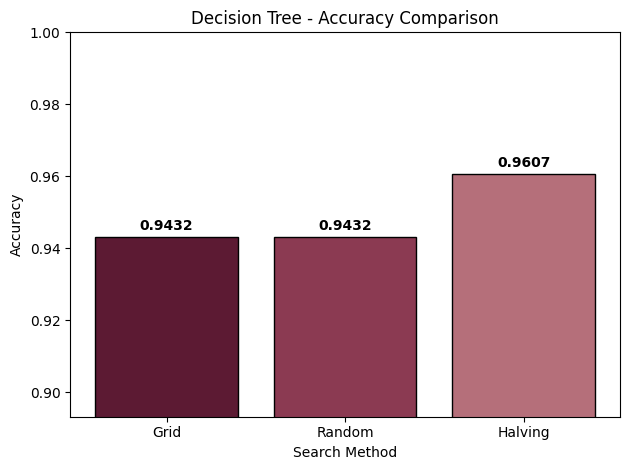

In [16]:
# Plot Accuracy Graph
# comparing accuracy of all three search methods
plt.figure()
bars = plt.bar(results.keys(), results.values(), color=['#5c1a33', '#8b3a52', '#b56f7a'], edgecolor='black')
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
plt.title("Decision Tree - Accuracy Comparison")
plt.xlabel("Search Method")
plt.ylabel("Accuracy")
plt.ylim(min(results.values()) - 0.05, 1.0)
plt.tight_layout()
plt.show()

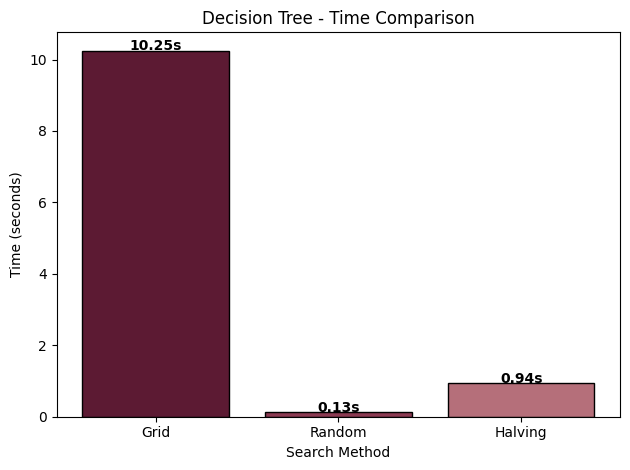

In [17]:
# Plot Time Graph
# comparing how long each method took to run
plt.figure()
bars = plt.bar(times.keys(), times.values(), color=['#5c1a33', '#8b3a52', '#b56f7a'], edgecolor='black')
for bar, val in zip(bars, times.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}s', ha='center', fontsize=10, fontweight='bold')
plt.title("Decision Tree - Time Comparison")
plt.xlabel("Search Method")
plt.ylabel("Time (seconds)")
plt.tight_layout()
plt.show()

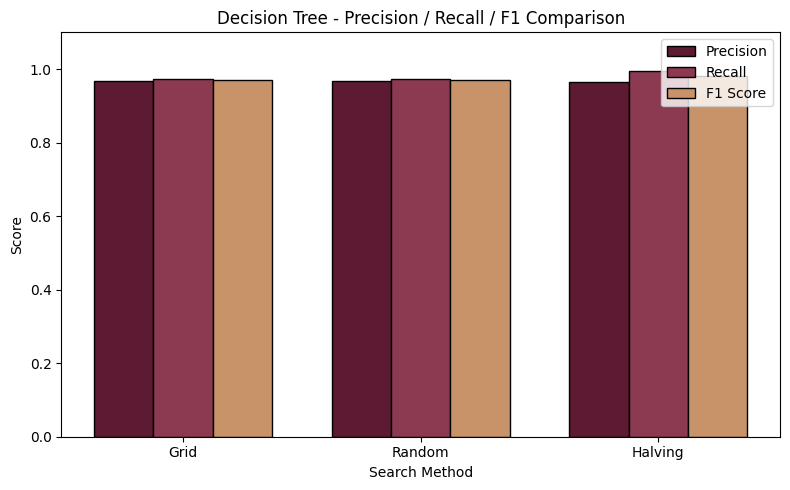

In [18]:
# Precision, Recall, F1 Comparison Graph
# grouped bar chart to see all three metrics side by side for each method
methods    = list(metrics.keys())
precision  = [metrics[m]['precision'] for m in methods]
recall     = [metrics[m]['recall']    for m in methods]
f1         = [metrics[m]['f1']        for m in methods]

x     = np.arange(len(methods))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width, precision, width, label='Precision', color='#5c1a33', edgecolor='black')
ax.bar(x,         recall,    width, label='Recall',    color='#8b3a52', edgecolor='black')
ax.bar(x + width, f1,        width, label='F1 Score',  color='#c9936a', edgecolor='black')

ax.set_title('Decision Tree - Precision / Recall / F1 Comparison')
ax.set_xlabel('Search Method')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

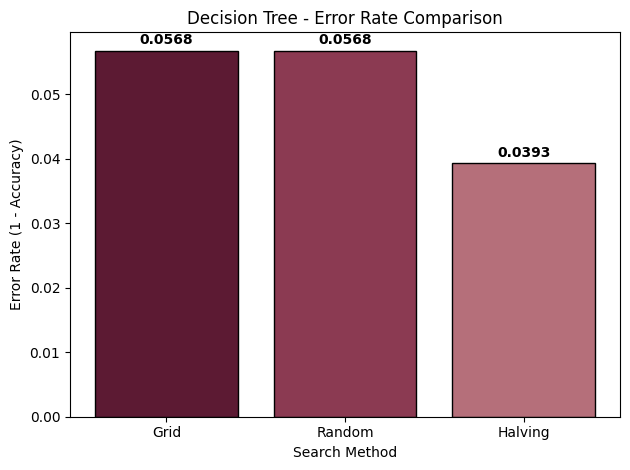

In [19]:
# Error Graph
# error = 1 - accuracy, shows how many samples were misclassified
errors = {m: 1 - acc for m, acc in results.items()}

plt.figure()
bars = plt.bar(errors.keys(), errors.values(), color=['#5c1a33', '#8b3a52', '#b56f7a'], edgecolor='black')
for bar, val in zip(bars, errors.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
plt.title("Decision Tree - Error Rate Comparison")
plt.xlabel("Search Method")
plt.ylabel("Error Rate (1 - Accuracy)")
plt.tight_layout()
plt.show()

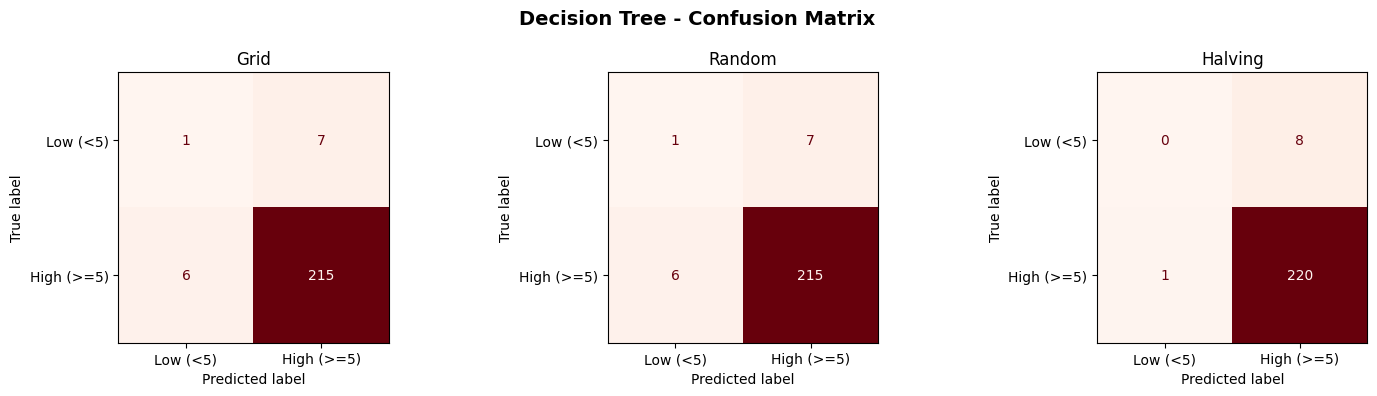

In [20]:
# Confusion Matrix for all three methods
# shows true positives, false positives, true negatives, false negatives
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Decision Tree - Confusion Matrix', fontsize=14, fontweight='bold')

for ax, (method, y_pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low (<5)', 'High (>=5)'])
    disp.plot(ax=ax, colorbar=False, cmap='Reds')
    ax.set_title(method)

plt.tight_layout()
plt.show()